<a href="https://colab.research.google.com/github/priyalimbu246/assignments/blob/main/Final_assignment1_Training_HOMO_LUMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CHEM 5610 — Final Project part 1: GNN Training
**Authors:** Priya N. Limbu, Bhola Gautam & Deepa Ranabhat  
**Title:** ML training using Graph Neural Network models (GCN and GIN) to predict the **HOMO-LUMO gap** from the QM9 dataset.

**Parameters:** Target properties HOMO & LUMO | Epochs **100** | Batch size **64** | Scheduler tolerance **1e-3**

### Outputs produced by this notebook (part2)
| File | Contents |
|------|---------|
| `best_gin.pt` | Best GIN model weights (preferred) |
| `best_gcn.pt` | Best GCN model weights (fallback) |
| `domain_stats.json` | Applicability-domain statistics for Notebook 2 |


## 1. Environment Setup

In [2]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q rdkit torch_geometric
else:
    # pip install rdkit torch_geometric  # uncomment if needed
    pass

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.4 MB/s eta 0:00:00


## 2. Imports

In [3]:
!pip install -q rdkit torch_geometric

# Standard libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math, os, random, json

# RDKit
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

# PyTorch & PyG
import torch
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU, Dropout
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GINConv, global_mean_pool, global_add_pool

# Sklearn metrics
from sklearn.metrics import mean_absolute_error, r2_score

# Progress bar
from tqdm.auto import tqdm
tqdm.pandas()

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 3. Download QM9 Dataset

In [4]:
%%bash
# Download QM9 CSV from public mirror (contains SMILES + 19 properties)
BASE_URL="https://deepchemdata.s3-us-west-1.amazonaws.com/datasets"

if [ ! -f qm9.csv ]; then
    wget -q "${BASE_URL}/qm9.csv" -O qm9.csv
    echo "Downloaded qm9.csv"
else
    echo "qm9.csv already exists"
fi

wc -l qm9.csv
head -2 qm9.csv


Downloaded qm9.csv
133886 qm9.csv
mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
gdb_1,C,157.7118,157.70997,157.70699,0,13.21,-0.3877,0.1171,0.5048,35.3641,0.044749,-40.47893,-40.476062,-40.475117,-40.498597,6.469,-395.999594594,-398.643290011,-401.014646522,-372.471772148


## 4. Load Properties CSV

QM9 property columns (from the original paper):  
mu, alpha, homo, lumo, gap, r2, zpve, u0, u298, h298, g298, cv, u0_atom, u298_atom, h298_atom, g298_atom, A, B, C

We target **gap** — the HOMO-LUMO gap in eV.


In [5]:
df = pd.read_csv("qm9.csv")
print(df.shape)
print(df.columns.tolist())
df.head()


(133885, 21)
['mol_id', 'smiles', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv', 'u0_atom', 'u298_atom', 'h298_atom', 'g298_atom']


,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,C,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,...,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,N,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,...,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,O,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,...,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171
3,gdb_4,C#C,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,...,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
4,gdb_5,C#N,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,...,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028


Target: gap
count    133885.000000
mean          0.251100
std           0.047519
min           0.024600
25%           0.216300
50%           0.249400
75%           0.288200
max           0.622100
Name: gap, dtype: float64


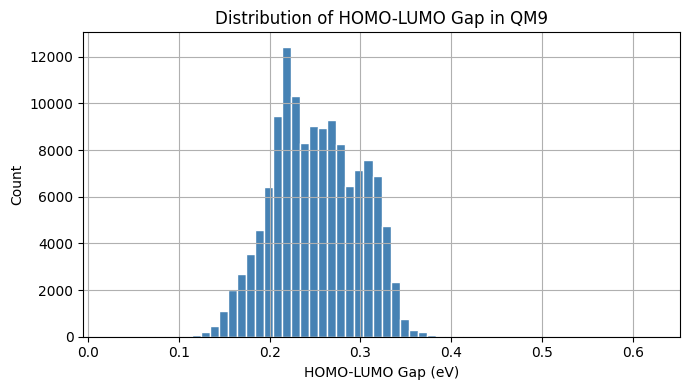

In [6]:
TARGET = "gap"  # HOMO-LUMO gap (eV)
print(f"Target: {TARGET}")
print(df[TARGET].describe())

plt.figure(figsize=(7, 4))
df[TARGET].hist(bins=60, color='steelblue', edgecolor='white')
plt.xlabel("HOMO-LUMO Gap (eV)")
plt.ylabel("Count")
plt.title("Distribution of HOMO-LUMO Gap in QM9")
plt.tight_layout()
plt.show()


## 5. Molecule-to-Graph Conversion

Each atom → **node** (one-hot encoded features).  
Each bond → two directed **edges** (undirected graph representation).

### Node features
- Atomic number (one-hot: H, C, N, O, F — HCONF only in QM9)
- Degree, Formal charge, Chiral tag
- Hybridization (S, SP, SP2, SP3, SP3D, SP3D2)
- Is aromatic, Number of Hs

### Edge features
- Bond type (single, double, triple, aromatic)
- Stereo, Is conjugated, Is in ring


In [7]:
ATOM_FEATURES = {
    "atomic_num":    [1, 6, 7, 8, 9],           # H, C, N, O, F
    "degree":        [0, 1, 2, 3, 4, 5],
    "formal_charge": [-1, 0, 1],
    "chiral_tag":    [0, 1, 2, 3],
    "hybridization": [
        Chem.rdchem.HybridizationType.S,
        Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
        Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2,
    ],
    "num_hs": [0, 1, 2, 3, 4],
}

BOND_FEATURES = {
    "bond_type": [
        Chem.rdchem.BondType.SINGLE,
        Chem.rdchem.BondType.DOUBLE,
        Chem.rdchem.BondType.TRIPLE,
        Chem.rdchem.BondType.AROMATIC,
    ],
    "stereo": [0, 1, 2, 3, 4, 5],
}


def one_hot(value, choices):
    """One-hot encode; unknown value maps to extra 'other' slot."""
    encoding = [0] * (len(choices) + 1)
    idx = choices.index(value) if value in choices else len(choices)
    encoding[idx] = 1
    return encoding


def atom_features(atom) -> list:
    feats = []
    feats += one_hot(atom.GetAtomicNum(),        ATOM_FEATURES["atomic_num"])
    feats += one_hot(atom.GetDegree(),           ATOM_FEATURES["degree"])
    feats += one_hot(atom.GetFormalCharge(),     ATOM_FEATURES["formal_charge"])
    feats += one_hot(int(atom.GetChiralTag()),   ATOM_FEATURES["chiral_tag"])
    feats += one_hot(atom.GetHybridization(),    ATOM_FEATURES["hybridization"])
    feats += one_hot(atom.GetTotalNumHs(),       ATOM_FEATURES["num_hs"])
    feats.append(int(atom.GetIsAromatic()))
    return feats


def bond_features(bond) -> list:
    feats = []
    feats += one_hot(bond.GetBondType(),    BOND_FEATURES["bond_type"])
    feats += one_hot(int(bond.GetStereo()), BOND_FEATURES["stereo"])
    feats.append(int(bond.GetIsConjugated()))
    feats.append(int(bond.IsInRing()))
    return feats


def mol_to_graph(mol, y=None):
    """Convert an RDKit molecule to a PyG Data object."""
    if mol is None:
        return None
    # Node features
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    # Edge features (undirected → two directed edges per bond)
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr  += [bf, bf]
    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros((0, 14), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    if y is not None:
        data.y = torch.tensor([y], dtype=torch.float)
    return data


def smi_to_graph(smi, y=None):
    mol = Chem.MolFromSmiles(smi)
    return mol_to_graph(mol, y)


# Sanity check
g = smi_to_graph("CCO", y=0.5)
print("Node features:", g.x.shape)
print("Edge index:   ", g.edge_index.shape)
print("Edge attr:    ", g.edge_attr.shape)


Node features: torch.Size([3, 36])
Edge index:    torch.Size([2, 4])
Edge attr:     torch.Size([4, 14])


## 6. Build Graph Dataset from QM9

In [8]:
# Set SUBSET to an integer (e.g. 20000) for quick testing; None = full dataset
SUBSET = None

if SUBSET:
    df_use = df.sample(n=SUBSET, random_state=SEED).reset_index(drop=True)
    print(f"Using subset of {SUBSET} molecules")
else:
    df_use = df.reset_index(drop=True)
    print(f"Using full dataset: {len(df_use)} molecules")

mol_graphs = []
skipped = 0

for i, row in tqdm(df_use.iterrows(), total=len(df_use), desc="Building graphs"):
    smi   = row["smiles"]
    y_val = row[TARGET]
    if pd.isna(y_val):
        skipped += 1
        continue
    g = smi_to_graph(smi, y=float(y_val))
    if g is not None:
        mol_graphs.append(g)
    else:
        skipped += 1

print(f"\nGraphs built: {len(mol_graphs)}  |  Skipped: {skipped}")
print(f"Node feature dim : {mol_graphs[0].num_features}")
print(f"Edge feature dim : {mol_graphs[0].num_edge_features}")


Using full dataset: 133885 molecules


Building graphs:   0%|          | 0/133885 [00:00<?, ?it/s]


Graphs built: 133885  |  Skipped: 0
Node feature dim : 36
Edge feature dim : 14


In [9]:
# Verify all graphs have consistent feature dimensions
node_dim = mol_graphs[0].num_features
edge_dim = mol_graphs[0].num_edge_features
bad = [i for i, g in enumerate(mol_graphs)
       if g.x.shape[1] != node_dim or g.edge_attr.shape[1] != edge_dim]
print(f"Graphs with inconsistent features: {len(bad)}")
for i in sorted(bad, reverse=True):
    del mol_graphs[i]
print(f"Graphs after cleanup: {len(mol_graphs)}")
print(f"Node feature dim : {mol_graphs[0].num_features}")
print(f"Edge feature dim : {mol_graphs[0].num_edge_features}")


Graphs with inconsistent features: 0
Graphs after cleanup: 133885
Node feature dim : 36
Edge feature dim : 14


## 7. Train / Validation / Test Split + DataLoaders

In [10]:
random.shuffle(mol_graphs)

n = len(mol_graphs)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

train_set = mol_graphs[:train_end]
val_set   = mol_graphs[train_end:val_end]
test_set  = mol_graphs[val_end:]

BATCH_SIZE = 64

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train:      {len(train_set):>7,} molecules  ({len(train_loader):>4} batches)")
print(f"Validation: {len(val_set):>7,} molecules  ({len(val_loader):>4} batches)")
print(f"Test:       {len(test_set):>7,} molecules  ({len(test_loader):>4} batches)")


Train:      107,108 molecules  (1674 batches)
Validation:  13,388 molecules  ( 210 batches)
Test:        13,389 molecules  ( 210 batches)


## 8. GNN Model Architectures

### Model A — GCN (Graph Convolutional Network)
Uses GCNConv layers, this is simple and fast.
### Model B — GIN (Graph Isomorphism Network)
Uses GINConv layers with MLP sub-networks and batch normalisation.  
Generally more expressive than GCN.


In [11]:
class GCN(torch.nn.Module):
    """Graph Convolutional Network for regression."""

    def __init__(self, dim_input, dim_hidden=128, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(dim_input,  dim_hidden)
        self.conv2 = GCNConv(dim_hidden, dim_hidden)
        self.conv3 = GCNConv(dim_hidden, dim_hidden)
        self.bn1   = BatchNorm1d(dim_hidden)
        self.bn2   = BatchNorm1d(dim_hidden)
        self.bn3   = BatchNorm1d(dim_hidden)
        self.lin1  = Linear(dim_hidden, dim_hidden // 2)
        self.lin2  = Linear(dim_hidden // 2, 1)
        self.drop  = Dropout(p=dropout)

    def forward(self, data):
        x, e, batch = data.x, data.edge_index, data.batch
        x = self.bn1(self.conv1(x, e).relu())
        x = self.bn2(self.conv2(x, e).relu())
        x = self.bn3(self.conv3(x, e).relu())
        x = global_mean_pool(x, batch)
        x = self.drop(x)
        x = self.lin1(x).relu()
        x = self.drop(x)
        return self.lin2(x)


class GIN(torch.nn.Module):
    """Graph Isomorphism Network for regression."""

    def _mlp(self, in_dim, out_dim):
        return Sequential(
            Linear(in_dim, out_dim), BatchNorm1d(out_dim), ReLU(),
            Linear(out_dim, out_dim), ReLU()
        )

    def __init__(self, dim_input, dim_hidden=128, dropout=0.3):
        super().__init__()
        self.conv1 = GINConv(self._mlp(dim_input,  dim_hidden))
        self.conv2 = GINConv(self._mlp(dim_hidden, dim_hidden))
        self.conv3 = GINConv(self._mlp(dim_hidden, dim_hidden))
        self.conv4 = GINConv(self._mlp(dim_hidden, dim_hidden))
        self.lin1  = Linear(dim_hidden, dim_hidden)
        self.lin2  = Linear(dim_hidden, dim_hidden // 2)
        self.lin3  = Linear(dim_hidden // 2, 1)
        self.drop  = Dropout(p=dropout)

    def forward(self, data):
        x, e, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, e).relu()
        x = self.conv2(x, e).relu()
        x = self.conv3(x, e).relu()
        x = self.conv4(x, e)
        x = global_add_pool(x, batch)
        x = self.lin1(x).relu()
        x = self.drop(x)
        x = self.lin2(x).relu()
        x = self.drop(x)
        return self.lin3(x)


print("Model classes defined.")


Model classes defined.


## 9. Training Utilities

In [12]:
def run_epoch(loader, model, loss_fn, optimizer=None):
    """One training or validation epoch. Pass optimizer=None for eval mode."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total = 0.0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            batch   = batch.to(device)
            batch.x = batch.x.float()
            pred    = model(batch)
            target  = batch.y.view(-1, 1)
            loss    = loss_fn(pred, target)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item() / len(loader)
    return total


def train_model(model, train_loader, val_loader,
                epochs=300, lr=1e-3, save_path="best_model.pt",
                scheduler_patience=20):
    """Full training loop with best-checkpoint saving and LR scheduler."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=scheduler_patience, factor=0.5)
    loss_fn   = torch.nn.MSELoss()

    train_losses, val_losses = [], []
    best_val = math.inf

    for epoch in range(1, epochs + 1):
        tr = run_epoch(train_loader, model, loss_fn, optimizer)
        vl = run_epoch(val_loader,   model, loss_fn)
        scheduler.step(vl)
        train_losses.append(tr)
        val_losses.append(vl)
        if vl < best_val:
            best_val = vl
            torch.save(model.state_dict(), save_path)
        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:>4}/{epochs} | "
                  f"Train MSE: {tr:.5f} | Val MSE: {vl:.5f} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    print(f"\nBest validation MSE: {best_val:.5f}  (saved → {save_path})")
    return train_losses, val_losses


def plot_loss_curves(train_loss, val_loss, title="Training Curve"):
    plt.figure(figsize=(8, 4))
    plt.plot(train_loss, label="Train MSE")
    plt.plot(val_loss,   label="Validation MSE")
    plt.yscale("log")
    plt.xlabel("Epoch"); plt.ylabel("MSE Loss (log scale)")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()


@torch.no_grad()
def evaluate_loader(loader, model):
    """Return numpy arrays of predictions and true values."""
    model.eval()
    preds, trues = [], []
    for batch in loader:
        batch   = batch.to(device)
        batch.x = batch.x.float()
        out  = model(batch).cpu().numpy().flatten()
        y    = batch.y.cpu().numpy().flatten()
        preds.extend(out); trues.extend(y)
    return np.array(preds), np.array(trues)


def plot_predictions(model, loaders_dict):
    """Scatter plot + residual plot for multiple data splits."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = {"Train": "steelblue", "Validation": "orange", "Test": "green"}
    all_true = []
    for split_name, loader in loaders_dict.items():
        preds, trues = evaluate_loader(loader, model)
        all_true.extend(trues)
        mae = mean_absolute_error(trues, preds)
        r2  = r2_score(trues, preds)
        lbl = f"{split_name} (MAE={mae:.3f}, R²={r2:.3f})"
        axes[0].scatter(preds, trues, alpha=0.3, s=5, label=lbl, color=colors[split_name])
        axes[1].scatter(preds, trues - preds, alpha=0.3, s=5, color=colors[split_name])
    diag = np.array([min(all_true), max(all_true)])
    axes[0].plot(diag, diag, 'r--', lw=1.5)
    axes[0].set_xlabel("Predicted HOMO-LUMO Gap (eV)")
    axes[0].set_ylabel("Actual HOMO-LUMO Gap (eV)")
    axes[0].set_title("Predicted vs. Actual"); axes[0].legend(fontsize=8)
    axes[1].axhline(0, color='black', lw=1)
    axes[1].set_xlabel("Predicted HOMO-LUMO Gap (eV)")
    axes[1].set_ylabel("Residual (Actual − Predicted)")
    axes[1].set_title("Residual Plot")
    plt.tight_layout(); plt.show()


def print_metrics(model, loaders_dict):
    print(f"{'Split':<12} {'MAE (eV)':>10} {'RMSE (eV)':>11} {'R²':>8}")
    print("-" * 44)
    for name, loader in loaders_dict.items():
        p, t = evaluate_loader(loader, model)
        mae  = mean_absolute_error(t, p)
        rmse = np.sqrt(np.mean((t - p)**2))
        r2   = r2_score(t, p)
        print(f"{name:<12} {mae:>10.4f} {rmse:>11.4f} {r2:>8.4f}")


## 10. Train GCN Model

In [13]:
DIM_INPUT = mol_graphs[0].num_features

model_gcn = GCN(dim_input=DIM_INPUT, dim_hidden=128, dropout=0.3).to(device)
print(model_gcn)
print(f"\nTotal parameters: {sum(p.numel() for p in model_gcn.parameters()):,}")


GCN(
  (conv1): GCNConv(36, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lin1): Linear(in_features=128, out_features=64, bias=True)
  (lin2): Linear(in_features=64, out_features=1, bias=True)
  (drop): Dropout(p=0.3, inplace=False)
)

Total parameters: 46,849


In [14]:
gcn_train_loss, gcn_val_loss = train_model(
    model_gcn, train_loader, val_loader,
    epochs=100, lr=1e-3,
    save_path="best_gcn.pt"
)


Epoch    1/100 | Train MSE: 0.00248 | Val MSE: 0.00032 | LR: 1.00e-03
Epoch   20/100 | Train MSE: 0.00020 | Val MSE: 0.00015 | LR: 1.00e-03
Epoch   40/100 | Train MSE: 0.00018 | Val MSE: 0.00015 | LR: 1.00e-03
Epoch   60/100 | Train MSE: 0.00017 | Val MSE: 0.00018 | LR: 1.00e-03
Epoch   80/100 | Train MSE: 0.00016 | Val MSE: 0.00013 | LR: 1.00e-03
Epoch  100/100 | Train MSE: 0.00016 | Val MSE: 0.00011 | LR: 1.00e-03

Best validation MSE: 0.00010  (saved → best_gcn.pt)


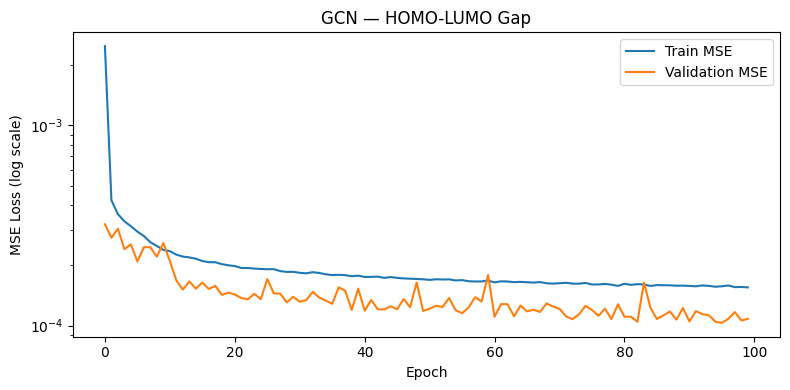

In [15]:
plot_loss_curves(gcn_train_loss, gcn_val_loss, title="GCN — HOMO-LUMO Gap")


Split          MAE (eV)   RMSE (eV)       R²
--------------------------------------------
Train            0.0065      0.0098   0.9571
Validation       0.0067      0.0102   0.9541
Test             0.0067      0.0099   0.9567


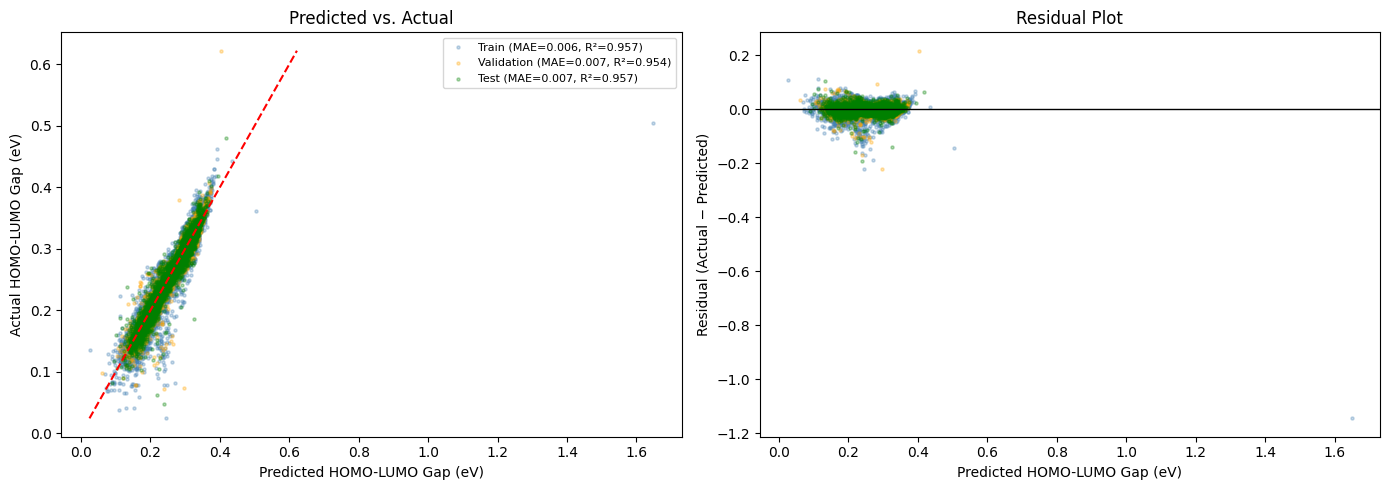

In [16]:
model_gcn.load_state_dict(torch.load("best_gcn.pt", map_location=device))

loaders = {"Train": train_loader, "Validation": val_loader, "Test": test_loader}
print_metrics(model_gcn, loaders)
plot_predictions(model_gcn, loaders)


## 11. Train GIN Model

In [17]:
model_gin = GIN(dim_input=DIM_INPUT, dim_hidden=128, dropout=0.3).to(device)
print(model_gin)
print(f"\nTotal parameters: {sum(p.numel() for p in model_gin.parameters()):,}")


GIN(
  (conv1): GINConv(nn=Sequential(
    (0): Linear(in_features=36, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (conv2): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (conv3): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (conv4): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum

In [21]:
gin_train_loss, gin_val_loss = train_model(
    model_gin, train_loader, val_loader,
    epochs=100, lr=1e-3,
    save_path="best_gin.pt"
)


Epoch    1/100 | Train MSE: 0.00011 | Val MSE: 0.00009 | LR: 1.00e-03
Epoch   20/100 | Train MSE: 0.00011 | Val MSE: 0.00009 | LR: 1.00e-03
Epoch   40/100 | Train MSE: 0.00011 | Val MSE: 0.00009 | LR: 1.00e-03
Epoch   60/100 | Train MSE: 0.00009 | Val MSE: 0.00008 | LR: 5.00e-04
Epoch   80/100 | Train MSE: 0.00008 | Val MSE: 0.00008 | LR: 2.50e-04
Epoch  100/100 | Train MSE: 0.00008 | Val MSE: 0.00008 | LR: 2.50e-04

Best validation MSE: 0.00007  (saved → best_gin.pt)


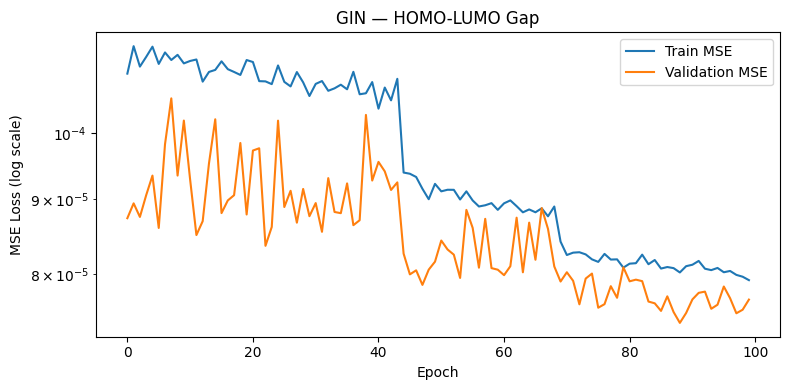

In [22]:
plot_loss_curves(gin_train_loss, gin_val_loss, title="GIN — HOMO-LUMO Gap")


Split          MAE (eV)   RMSE (eV)       R²
--------------------------------------------
Train            0.0039      0.0054   0.9872
Validation       0.0050      0.0086   0.9670
Test             0.0049      0.0078   0.9731


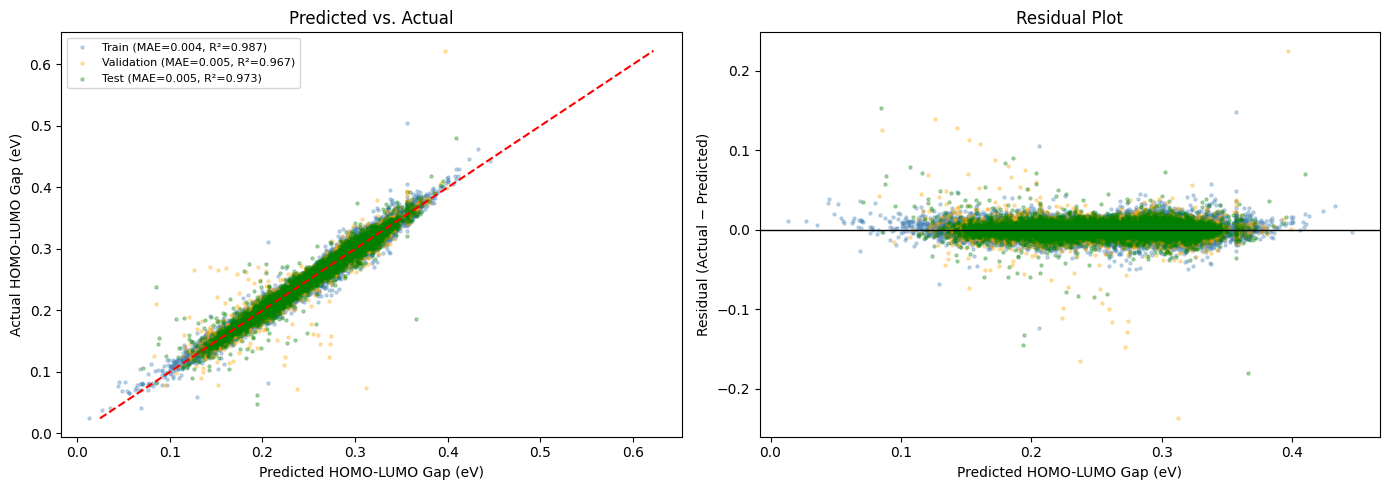

In [23]:
model_gin.load_state_dict(torch.load("best_gin.pt", map_location=device))

loaders = {"Train": train_loader, "Validation": val_loader, "Test": test_loader}
print_metrics(model_gin, loaders)
plot_predictions(model_gin, loaders)


## 12. Compare GCN vs. GIN

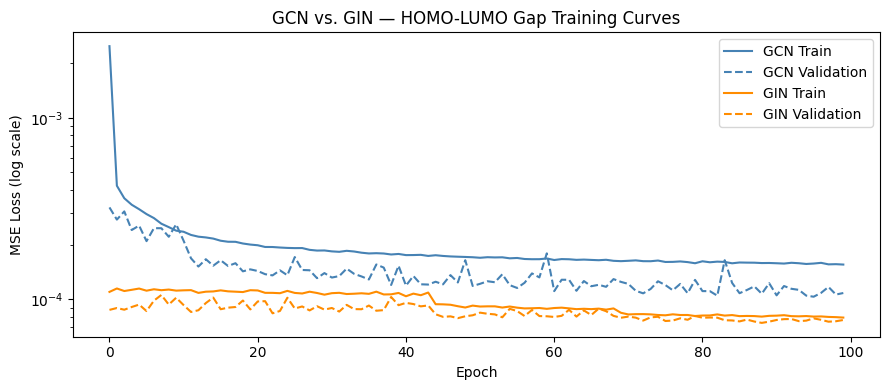

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(gcn_train_loss, label="GCN Train",       color="steelblue",  ls="-")
ax.semilogy(gcn_val_loss,   label="GCN Validation",  color="steelblue",  ls="--")
ax.semilogy(gin_train_loss, label="GIN Train",        color="darkorange", ls="-")
ax.semilogy(gin_val_loss,   label="GIN Validation",   color="darkorange", ls="--")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (log scale)")
ax.set_title("GCN vs. GIN — HOMO-LUMO Gap Training Curves")
ax.legend(); plt.tight_layout(); plt.show()


In [25]:
print("=== GCN ===")
model_gcn.load_state_dict(torch.load("best_gcn.pt", map_location=device))
print_metrics(model_gcn, {"Train": train_loader, "Validation": val_loader, "Test": test_loader})

print("\n=== GIN ===")
model_gin.load_state_dict(torch.load("best_gin.pt", map_location=device))
print_metrics(model_gin, {"Train": train_loader, "Validation": val_loader, "Test": test_loader})


=== GCN ===
Split          MAE (eV)   RMSE (eV)       R²
--------------------------------------------
Train            0.0065      0.0098   0.9571
Validation       0.0067      0.0102   0.9541
Test             0.0067      0.0099   0.9567

=== GIN ===
Split          MAE (eV)   RMSE (eV)       R²
--------------------------------------------
Train            0.0039      0.0054   0.9872
Validation       0.0050      0.0086   0.9670
Test             0.0049      0.0078   0.9731


## 13. Save Applicability Domain Statistics

We record the distribution of molecular descriptors from the **training set** so that
Notebook 2 can flag molecules that fall outside the model's applicability domain.  
Saves: domain_stats.json


In [26]:
def mol_descriptors(mol):
    """Compute simple scalar descriptors for applicability domain checks."""
    return {
        "mw":        Descriptors.MolWt(mol),
        "logp":      Descriptors.MolLogP(mol),
        "hbd":       rdMolDescriptors.CalcNumHBD(mol),
        "hba":       rdMolDescriptors.CalcNumHBA(mol),
        "rotbonds":  rdMolDescriptors.CalcNumRotatableBonds(mol),
        "rings":     rdMolDescriptors.CalcNumRings(mol),
        "num_atoms": mol.GetNumAtoms(),
        "num_heavy": mol.GetNumHeavyAtoms(),
    }

# Compute descriptors for training molecules
train_smiles = [df_use["smiles"].iloc[i] for i in range(train_end)]
desc_list = []
for smi in tqdm(train_smiles, desc="Computing applicability stats"):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        desc_list.append(mol_descriptors(mol))

desc_df = pd.DataFrame(desc_list)
print(desc_df.describe())

# Build domain_stats dict
domain_stats = {}
for col in desc_df.columns:
    domain_stats[col] = {
        "mean": float(desc_df[col].mean()),
        "std":  float(desc_df[col].std()),
        "min":  float(desc_df[col].min()),
        "max":  float(desc_df[col].max()),
        "q01":  float(desc_df[col].quantile(0.01)),
        "q99":  float(desc_df[col].quantile(0.99)),
    }

# Record element set and max heavy-atom count seen in training
train_elements = set()
for smi in train_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        for atom in mol.GetAtoms():
            train_elements.add(atom.GetSymbol())

domain_stats["_elements"]       = sorted(list(train_elements))
domain_stats["_max_heavy_atoms"] = int(desc_df["num_heavy"].max())
domain_stats["_target"]          = TARGET

with open("domain_stats.json", "w") as f:
    json.dump(domain_stats, f, indent=2)

print("\nSaved domain_stats.json")
print("Training elements :", domain_stats["_elements"])
print("Max heavy atoms   :", domain_stats["_max_heavy_atoms"])


Computing applicability stats:   0%|          | 0/107108 [00:00<?, ?it/s]

                  mw           logp            hbd            hba  \
count  107108.000000  107108.000000  107108.000000  107108.000000   
mean      121.741854       0.296559       0.799669       2.109124   
std         7.987046       1.001347       0.830014       0.975124   
min        16.043000      -4.909700       0.000000       0.000000   
25%       120.155000      -0.346400       0.000000       1.000000   
50%       124.143000       0.282200       1.000000       2.000000   
75%       126.199000       0.952700       1.000000       3.000000   
max       141.092000       3.612800       5.000000       6.000000   

            rotbonds          rings      num_atoms      num_heavy  
count  107108.000000  107108.000000  107108.000000  107108.000000  
mean        0.783732       1.825895       8.744828       8.744828  
std         1.023802       1.249360       0.557478       0.557478  
min         0.000000       0.000000       1.000000       1.000000  
25%         0.000000       1.000000   